In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel(
    '../../../data/titanic3.xls'
)

In [3]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [4]:
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [5]:
cols_with_nans = df.isna().sum()[df.isna().sum() > 0]

cols_with_nans = cols_with_nans.to_frame(name = 'count_of_nans')
cols_with_nans['percentage_of_total_rows'] = (cols_with_nans['count_of_nans']/len(df)*100).round(2)
cols_with_nans

# age: I would fill it with the mean
# fare: only 1 missing value, I would replace it with the median
# cabin: ~77% is missing, which is significant, but I don’t think it’s an important feature, so I wouldn’t use this column
# embarked: two missing values, but I’m not sure what to fill them with, so I would remove them
# boat: out of 823, 800 are NaN for the deceased, so for them I would change it to 'did_not_board_boat', and for survivors just 'unknown'
# body: this has the highest percentage of NaN, but 500 of these are survivors (so no body number), and the remaining 688 are likely missing bodies
# home.dest: could be filled with the most frequent value

,count_of_nans,percentage_of_total_rows
age,263,20.09
fare,1,0.08
cabin,1014,77.46
embarked,2,0.15
boat,823,62.87
body,1188,90.76
home.dest,564,43.09


In [6]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [7]:
df[df['survived'] == 1]['body'].isna().sum()

np.int64(500)

In [8]:
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

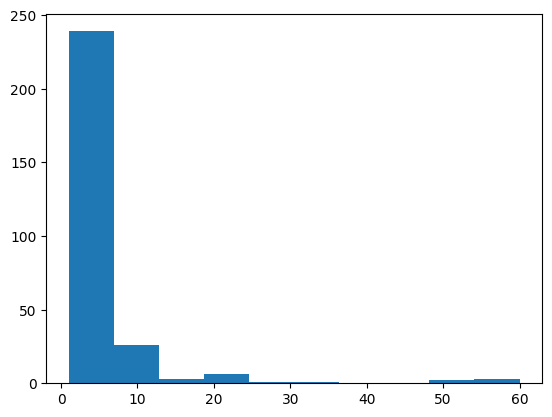

In [9]:
import matplotlib.pyplot as plt

fare = df['fare'].value_counts().to_frame()

fig, ax = plt.subplots()

ax.hist(fare['count'])

plt.show()

In [10]:
fare.dtypes

count    int64
dtype: object

In [11]:
fare

,count
fare,
8.0500,60
13.0000,59
7.7500,55
26.0000,50
7.8958,49
...,...
9.3250,1
7.7792,1
9.8375,1


In [12]:
df[df['survived'] == 1]['cabin'].isna().sum()

np.int64(307)

In [13]:
df[df['survived'] == 1]['body'].isna().sum()

np.int64(500)

In [14]:
df['home.dest'].value_counts()

home.dest
New York, NY                      64
London                            14
Montreal, PQ                      10
Paris, France                      9
Cornwall / Akron, OH               9
                                  ..
Waukegan, Chicago, IL              1
Myren, Sweden New York, NY         1
Finland Sudbury, ON                1
Oslo, Norway Cameron, WI           1
Antwerp, Belgium / Stanton, OH     1
Name: count, Length: 369, dtype: int64

#### Beyond the exercise_1
##### Create a series (`most_common_destinations`) in which the index contains the unique values from the `embarked` column and the values are the most common destination for each value of `embarked`.

In [15]:
embarked_list = list(df['embarked'].dropna().unique())
for i in embarked_list:
    print(f"{i} -> {df[df['embarked'] == i]['home.dest'].value_counts().index[0]}")

S -> New York, NY
C -> New York, NY
Q -> Ireland Chicago, IL


In [16]:
embarked_list = list(df['embarked'].dropna().unique())

data_for_series = {}
for i in embarked_list:
    value = df[df['embarked'] == i]['home.dest'].value_counts().index[0]
    data_for_series.update({i:value})

most_common_destinations = pd.Series(data_for_series)
most_common_destinations

S           New York, NY
C           New York, NY
Q    Ireland Chicago, IL
dtype: str

#### Beyond the exercise_2
##### Replace `NaN` values in the `home.dest` column with values from `embarked`. (Because values in `embarked` and `home.dest` are distinct, this is an OK middle step.)

In [17]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [18]:
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [19]:
# df['home.dest'] = df['home.dest'].fillna(df['embarked'])

In [20]:
conditions = [
    df['embarked'] == 'S',
    df['embarked'] == 'C',
    df['embarked'] == 'Q',
    
]

conditional_values = [
    'maybe_Southampton',
    'maybe_Cherbourg',
    'maybe_Queenstown'
]

df['home.dest'] = df['home.dest'].fillna(
    pd.Series(np.select(conditions, conditional_values, ['unknown']) # here i have to convert the numpy array to a pandas series to make it compatible with fillna()
    )
)

df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest       0
dtype: int64

In [21]:
df.groupby('home.dest')['home.dest'].value_counts().sort_values(ascending= False).head(20)

home.dest
maybe_Southampton                            379
maybe_Cherbourg                               98
maybe_Queenstown                              86
New York, NY                                  64
London                                        14
Montreal, PQ                                  10
Cornwall / Akron, OH                           9
Paris, France                                  9
Philadelphia, PA                               8
Wiltshire, England Niagara Falls, NY           8
Winnipeg, MB                                   8
Belfast                                        7
Brooklyn, NY                                   7
Sweden Winnipeg, MN                            7
Sweden Worcester, MA                           5
Haverford, PA / Cooperstown, NY                5
Somerset / Bernardsville, NJ                   5
Ottawa, ON                                     5
Rotherfield, Sussex, England Essex Co, MA      5
Bulgaria Chicago, IL                           5
Name: coun

In [22]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,maybe_Cherbourg
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,maybe_Cherbourg
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,maybe_Cherbourg
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,maybe_Cherbourg


#### Beyond the exercise_3
##### Because `fillna` returns a series, we assign the result back to `df['home.dest']`, replacing the original column with the new, null-free, column.

In [23]:
# in this task I realized that what I did in Beyond Exercise 2 was unnecessarily complicated
# and was just an intermediate step, anyway :D
most_common_destinations = pd.Series(
    ['New York, NY', 'New York, NY', 'Ireland Chicago, IL'],
    index=['maybe_Southampton', 'maybe_Cherbourg', 'maybe_Queenstown']
)

most_common_destinations

maybe_Southampton           New York, NY
maybe_Cherbourg             New York, NY
maybe_Queenstown     Ireland Chicago, IL
dtype: str

In [24]:
df['home.dest'] = df['home.dest'].replace(most_common_destinations)

In [25]:
df.groupby('home.dest')['home.dest'].value_counts().sort_values(ascending= False).head(20)

home.dest
New York, NY                                 541
Ireland Chicago, IL                           90
London                                        14
Montreal, PQ                                  10
Cornwall / Akron, OH                           9
Paris, France                                  9
Wiltshire, England Niagara Falls, NY           8
Philadelphia, PA                               8
Winnipeg, MB                                   8
Brooklyn, NY                                   7
Belfast                                        7
Sweden Winnipeg, MN                            7
Bulgaria Chicago, IL                           5
Ottawa, ON                                     5
Haverford, PA / Cooperstown, NY                5
Rotherfield, Sussex, England Essex Co, MA      5
Somerset / Bernardsville, NJ                   5
Sweden Worcester, MA                           5
Bournmouth, England                            4
Ruotsinphytaa, Finland New York, NY            4
Name: coun